# Diagnóstico Solar Municipal — Departamento de Cortés

**Proyecto de Sostenibilidad (Parcial 1) — Línea base ambiental**
Autor: Diego Cárcamo

Este notebook calcula, a partir de datos ráster del *Global Solar Atlas*, dos indicadores de
potencial solar para los **298 municipios de Honduras** y los examina en detalle para el
territorio elegido: el **departamento de Cortés (12 municipios)**.

- **GHI** (*Global Horizontal Irradiance*, kWh/m²/año): irradiación solar total recibida por
  una superficie horizontal. Es el indicador climático "crudo" del recurso solar.
- **PVOUT** (*Photovoltaic Power Output*, kWh/kWp/año): generación eléctrica estimada de un
  sistema fotovoltaico típico por cada kWp instalado. Ya incorpora pérdidas de temperatura,
  inversor y sistema, por lo que es el indicador más cercano a la **viabilidad real de un
  proyecto solar**.

En la versión anterior de este notebook solo se procesaba GHI. Aquí se agrega el
procesamiento de PVOUT (que ya estaba disponible como insumo pero no se usaba) y se reportan
ambos indicadores **por separado**, ya que están altamente correlacionados a nivel nacional
(r ≈ 0.99) y fusionarlos en un solo número no aportaría información adicional — mostrarlos
por separado sí permite distinguir "cuánto sol llega" de "cuánta electricidad se generaría".

In [1]:
import sys
from pathlib import Path

import fiona
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterstats import zonal_stats

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().parent  # raíz del proyecto (este notebook vive en /notebooks)
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Rutas de datos
GDB_PATH = ROOT / "data/boundaries/raw/hnd_admin_boundaries.gdb"
RASTER_DIR = ROOT / "data/GIS_Data_SolarPower/raw/Honduras_GISdata_LTAy_YearlyMonthlyTotals_GlobalSolarAtlas-v2_GEOTIFF"
GHI_PATH = RASTER_DIR / "GHI.tif"
PVOUT_PATH = RASTER_DIR / "PVOUT.tif"

INDICADORES_PATH = ROOT / "data/index/processed/dataset_indicadores_municipales.csv"
OUTPUT_ENRIQUECIDO = ROOT / "data/index/processed/dataset_indicadores_municipales_enriquecido.csv"

DEPARTAMENTO_FOCO = "HN05"  # Cortés
NOMBRE_DEPARTAMENTO_FOCO = "Cortes"


## 1. Capas administrativas

La geodatabase tiene varias capas; `hnd_admin2` es el nivel municipal (298 municipios), que
es la unidad de análisis que necesitamos (no `hnd_admin1`, que son los 18 departamentos).

In [2]:
capas = fiona.listlayers(GDB_PATH)
for i, capa in enumerate(capas):
    print(f"[{i}] {capa}")

# admin2 = municipios (nivel de análisis). admin1 sería departamentos.
municipios_gdf = gpd.read_file(GDB_PATH, layer="hnd_admin2")
print(f"\nMunicipios cargados: {len(municipios_gdf)}")
print(f"CRS: {municipios_gdf.crs}")


[0] hnd_admin0
[1] hnd_admin1
[2] hnd_admin2
[3] hnd_adminlines
[4] hnd_adminpoints
[5] hnd_populatedplaces



Municipios cargados: 298
CRS: EPSG:4326


## 2. Estadísticas zonales — GHI y PVOUT

Para cada municipio calculamos media, mínimo, máximo y conteo de píxeles del ráster que caen
dentro de su polígono (`all_touched=False`, es decir: el centro del píxel debe estar dentro
del límite, para mayor precisión espacial).

**Nota de resolución:** el ráster de GHI tiene una grilla de 2400×3200 (~1 km/píxel) mientras
que el de PVOUT es más grueso, 720×960 (~3 km/píxel). Esto significa que los municipios
pequeños quedan representados por muy pocos píxeles de PVOUT — lo reportamos como
`pvout_count` para que quede documentado como limitación de calidad de datos, tal como pide
la metodología del proyecto.

In [3]:
def zonal_municipal_df(vectors, raster_path, prefix):
    """Calcula estadísticas zonales (mean/min/max/count) de un ráster por municipio
    y devuelve un DataFrame limpio con columnas prefijadas (p.ej. 'ghi_mean').
    Reutilizable para cualquier ráster de recurso solar (GHI, PVOUT, GTI, etc.)."""
    stats = zonal_stats(
        vectors=vectors,
        raster=str(raster_path),
        stats=["mean", "min", "max", "count"],
        geojson_out=True,
        all_touched=False,
    )
    gdf_stats = gpd.GeoDataFrame.from_features(stats)

    rename_map = {
        "adm1_name": "departamento",
        "adm2_name": "municipio",
        "adm1_pcode": "codigo_departamental",
        "adm2_pcode": "codigo_municipal",
        "mean": f"{prefix}_mean",
        "min": f"{prefix}_min",
        "max": f"{prefix}_max",
        "count": f"{prefix}_count",
    }
    out = gdf_stats[list(rename_map.keys())].rename(columns=rename_map)

    for col in ["departamento", "municipio"]:
        out[col] = (
            out[col]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
            .str.title()
        )
    return out


ghi_df = zonal_municipal_df(municipios_gdf, GHI_PATH, "ghi")
pvout_df = zonal_municipal_df(municipios_gdf, PVOUT_PATH, "pvout")

solar_df = ghi_df.merge(
    pvout_df.drop(columns=["departamento"]),
    on=["municipio", "codigo_departamental", "codigo_municipal"],
    validate="one_to_one",
)

print(f"Municipios procesados: {len(solar_df)}")
solar_df.head()


Municipios procesados: 298


,departamento,municipio,codigo_departamental,codigo_municipal,ghi_mean,ghi_min,ghi_max,ghi_count,pvout_mean,pvout_min,pvout_max,pvout_count
0,Islas De La Bahia,Guanaja,HN11,HN1102,1988.934501,1898.935059,2023.484985,771,1627.964844,1595.411987,1649.468994,72
1,Islas De La Bahia,Jose Santos Guardiola,HN11,HN1103,2012.974138,1978.923950,2032.615967,870,1642.248297,1632.667969,1660.061035,78
2,Islas De La Bahia,Roatan,HN11,HN1101,2009.962306,1982.577026,2054.895996,902,1636.919063,1627.188965,1669.192017,75
3,Colon,Trujillo,HN02,HN0201,1964.558803,1748.086060,2042.113037,12899,1584.741458,1476.706055,1652.390991,1156
4,Colon,Iriona,HN02,HN0203,1791.207199,1471.227051,1977.828979,52008,1455.313328,1264.130005,1602.717041,4682


## 3. Dataset municipal enriquecido

El CSV de indicadores municipales (`dataset_indicadores_municipales.csv`) ya traía el GHI
precalculado como `solar_power_mean/min/max` (de una corrida anterior de este mismo
procesamiento). Antes de fusionar, verificamos que nuestro cálculo de GHI coincide con esa
columna — es una prueba de consistencia barata que confirma que ambos vienen de la misma
fuente — y agregamos las columnas de PVOUT, que es la parte nueva.

In [4]:
indicadores = pd.read_csv(INDICADORES_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

# --- Prueba de consistencia: nuestro GHI recién calculado vs. el ya existente en el CSV ---
chequeo = indicadores.merge(
    solar_df[["codigo_municipal", "ghi_mean"]], on="codigo_municipal", how="inner"
)
diferencia_max = (chequeo["solar_power_mean"] - chequeo["ghi_mean"]).abs().max()
print(f"Diferencia máxima entre solar_power_mean (CSV) y ghi_mean (recalculado): {diferencia_max:.6f}")
assert diferencia_max < 1e-3, "El GHI recalculado no coincide con el del CSV: revisar el ráster/capa usados."

# --- Fusión: solo agregamos las columnas nuevas de PVOUT ---
enriquecido = indicadores.merge(
    solar_df[["codigo_municipal", "pvout_mean", "pvout_min", "pvout_max", "pvout_count"]],
    on="codigo_municipal",
    how="left",
    validate="one_to_one",
)

assert enriquecido["pvout_mean"].isnull().sum() == 0, "Quedaron municipios sin PVOUT tras la fusión."

enriquecido.to_csv(OUTPUT_ENRIQUECIDO, index=False, encoding="utf-8-sig")
print(f"Dataset enriquecido exportado: {OUTPUT_ENRIQUECIDO.name}  ({enriquecido.shape[0]} filas, {enriquecido.shape[1]} columnas)")


Diferencia máxima entre solar_power_mean (CSV) y ghi_mean (recalculado): 0.000000
Dataset enriquecido exportado: dataset_indicadores_municipales_enriquecido.csv  (298 filas, 22 columnas)


## 4. Filtrado al territorio de estudio: Cortés (12 municipios)

Por lineamiento del proyecto, el diagnóstico se desarrolla sobre **un único territorio**. Se
eligió el **departamento de Cortés** (código `HN05`), que agrupa **12 municipios** — de aquí
en adelante todo el análisis (este notebook y el del índice compuesto) se enfoca en ese
subconjunto.

In [5]:
cortes = enriquecido[enriquecido["codigo_departamental"] == DEPARTAMENTO_FOCO].copy()
cortes = cortes.sort_values("municipio").reset_index(drop=True)

assert len(cortes) == 12, f"Se esperaban 12 municipios en Cortés, se obtuvieron {len(cortes)}"

columnas_mostrar = [
    "municipio", "solar_power_mean", "solar_power_min", "solar_power_max",
    "pvout_mean", "pvout_min", "pvout_max", "pvout_count",
]
cortes[columnas_mostrar]


,municipio,solar_power_mean,solar_power_min,solar_power_max,pvout_mean,pvout_min,pvout_max,pvout_count
0,Choloma,1880.486177,1506.291016,1964.680054,1523.873900,1280.201050,1584.453979,568
1,La Lima,1969.962451,1944.956055,1990.612061,1582.066866,1565.461060,1597.968994,136
2,Omoa,1773.281026,1502.637939,1946.781982,1434.468620,1256.824951,1566.921997,482
3,Pimienta,1973.704833,1924.136963,1994.630005,1581.178079,1558.886963,1593.586060,68
4,Potrerillos,1985.603731,1916.102051,2026.041992,1589.806409,1555.599976,1616.962036,118
5,Puerto Cortes,1935.149874,1793.011963,2006.683960,1568.190027,1478.896973,1622.806030,470
6,San Antonio De Cortes,1946.788571,1695.490967,2025.676025,1568.550651,1488.759033,1616.962036,269
7,San Francisco De Yojoa,1971.034796,1859.488037,2022.024048,1582.821691,1536.607056,1612.943970,119
8,San Manuel,1965.433403,1908.796021,1985.499023,1576.124632,1551.217041,1592.125000,170
9,San Pedro Sula,1765.359245,1331.701050,1989.516968,1437.203739,1125.699951,1597.238037,1043


## 5. Análisis descriptivo — GHI vs. PVOUT en los 12 municipios de Cortés

Con solo 12 observaciones, un histograma de 10 bins (como en la versión anterior de este
notebook) no es representativo — la mayoría de los bins quedarían vacíos o con 1 dato. En su
lugar usamos:

1. Un **gráfico de rango** (media + min–max observado) por municipio para GHI y otro para
   PVOUT — esto además aprovecha las columnas `min`/`max` que ya calculábamos pero nunca
   graficábamos.
2. Un **dispersograma GHI vs. PVOUT** para verificar qué tan alineados están ambos
   indicadores dentro de Cortés.

Paleta: un solo tono por gráfico (azul para GHI, naranja para PVOUT) — el color no está
codificando ninguna categoría real entre municipios, así que usar un color arbitrario por
barra (como en la versión anterior) sería ruido visual, no información.

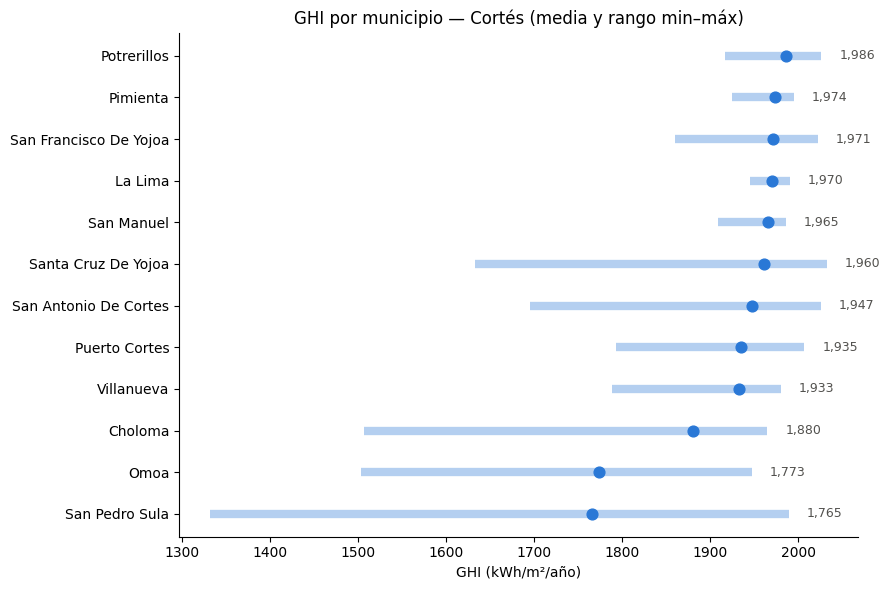

In [6]:
AZUL = "#2a78d6"      # GHI
NARANJA = "#eb6834"   # PVOUT
GRIS_TEXTO = "#52514e"


def grafico_rango_por_municipio(data, col_mean, col_min, col_max, color, titulo, xlabel):
    """Gráfico de rango: punto = media, línea = min-max observado en el municipio.
    Ordenado descendente por la media."""
    d = data.sort_values(col_mean, ascending=False)
    y_pos = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hlines(y_pos, d[col_min], d[col_max], color=color, alpha=0.35, linewidth=6)
    ax.scatter(d[col_mean], y_pos, color=color, s=60, zorder=3, label="Media")

    for y, (_, row) in zip(y_pos, d.iterrows()):
        ax.text(row[col_max] + (d[col_max].max() * 0.01), y, f"{row[col_mean]:,.0f}",
                va="center", fontsize=9, color=GRIS_TEXTO)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(d["municipio"])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(titulo)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


grafico_rango_por_municipio(
    cortes, "solar_power_mean", "solar_power_min", "solar_power_max", AZUL,
    "GHI por municipio — Cortés (media y rango min–máx)",
    "GHI (kWh/m²/año)",
)


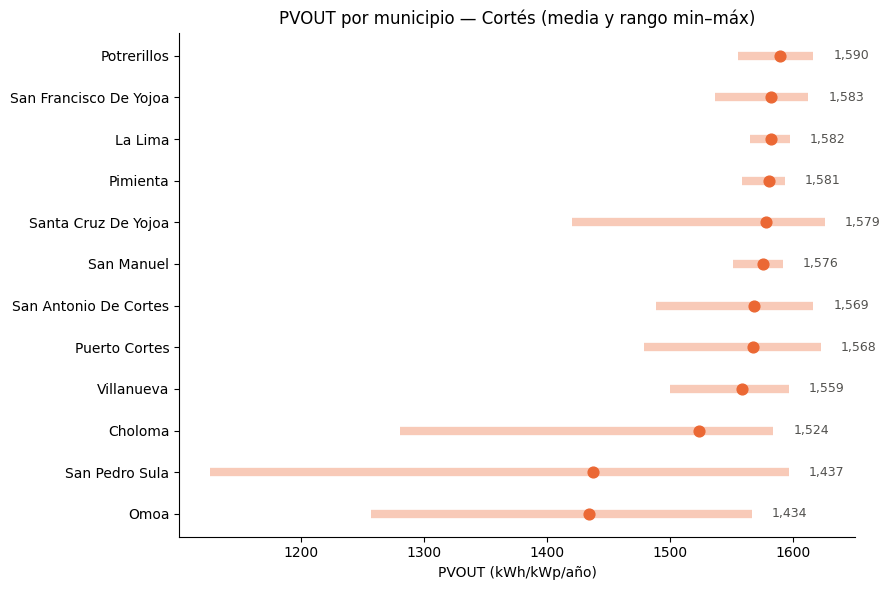

In [7]:
grafico_rango_por_municipio(
    cortes, "pvout_mean", "pvout_min", "pvout_max", NARANJA,
    "PVOUT por municipio — Cortés (media y rango min–máx)",
    "PVOUT (kWh/kWp/año)",
)


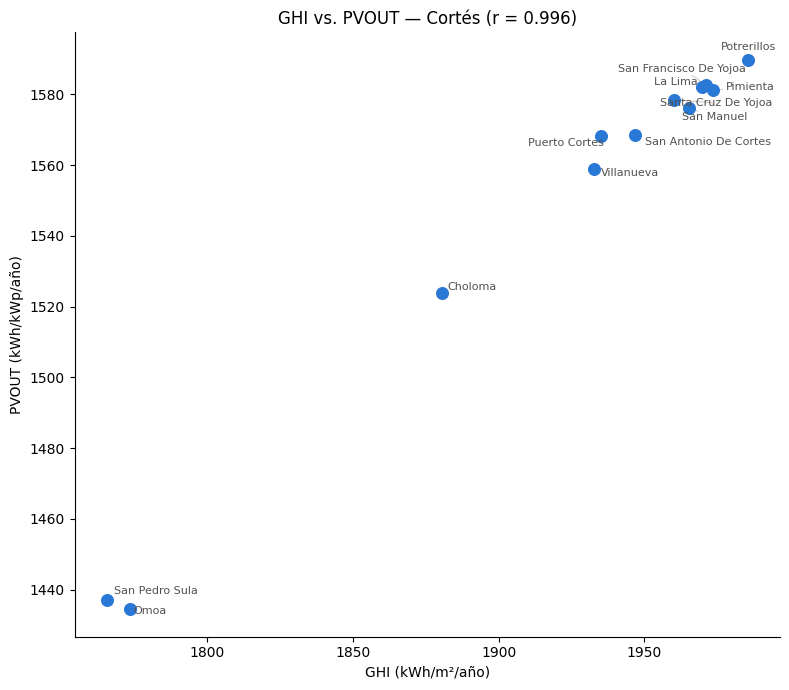

Correlación GHI-PVOUT en Cortés: r = 0.996


In [8]:
correlacion = cortes["solar_power_mean"].corr(cortes["pvout_mean"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(cortes["solar_power_mean"], cortes["pvout_mean"], color=AZUL, s=70, zorder=3)

etiquetas = [
    ax.text(row["solar_power_mean"], row["pvout_mean"], row["municipio"], fontsize=8, color=GRIS_TEXTO)
    for _, row in cortes.iterrows()
]
try:
    from adjustText import adjust_text
    adjust_text(etiquetas, ax=ax, arrowprops=dict(arrowstyle="-", color="#c3c2b7", lw=0.6))
except ImportError:
    print("Sugerencia: 'pip install adjustText' evita que las etiquetas de municipios se encimen.")

ax.set_xlabel("GHI (kWh/m²/año)")
ax.set_ylabel("PVOUT (kWh/kWp/año)")
ax.set_title(f"GHI vs. PVOUT — Cortés (r = {correlacion:.3f})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Correlación GHI-PVOUT en Cortés: r = {correlacion:.3f}")


## 6. Estadísticos descriptivos (tabla)

Complementa los gráficos de arriba con media, desviación estándar, coeficiente de variación
y rango para ambos indicadores dentro de Cortés.

In [9]:
resumen = pd.DataFrame({
    "GHI (kWh/m2/anio)": cortes["solar_power_mean"].describe(),
    "PVOUT (kWh/kWp/anio)": cortes["pvout_mean"].describe(),
})
resumen.loc["cv"] = resumen.loc["std"] / resumen.loc["mean"]
resumen.round(2)


,GHI (kWh/m2/anio),PVOUT (kWh/kWp/anio)
count,12.00,12.00
mean,1921.66,1548.48
std,76.31,55.30
min,1765.36,1434.47
25%,1919.73,1550.23
50%,1953.57,1572.34
75%,1970.23,1581.40
max,1985.60,1589.81
cv,0.04,0.04


## 7. Conclusión del bloque ambiental

- GHI y PVOUT están casi perfectamente correlacionados dentro de Cortés (r ≈ 0.9–1.0), como
  es esperable físicamente: PVOUT es, a grandes rasgos, GHI convertido a energía eléctrica
  con un factor de rendimiento del sistema relativamente estable en un área geográfica
  pequeña. Esto es relevante para el índice compuesto: incluir ambas variables normalizadas
  en la misma suma ponderada sería redundante (multicolinealidad), así que en el notebook del
  índice se usa **PVOUT** como variable solar del índice (por ser la más cercana a
  "generación eléctrica real"), y **GHI** se reporta aquí solo con fines descriptivos y de
  contexto.
- El dataset enriquecido (`dataset_indicadores_municipales_enriquecido.csv`) queda exportado
  y es el insumo del notebook `hn_index_part2.ipynb`, donde se construye el índice compuesto
  y la preselección final de municipios.